# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')

from joblib import Parallel, delayed


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.variables import *
from core.m_out_of_n_bootstrap import choose_best_m
from core.dgp import SingleSegmentWithoutControl as SingleSegment
import core.treatment_selection as ts

# DGP

In [5]:
dgp = SingleSegment(
    te_arr = np.array([0.1, 0.15]), noise_std=1
)
treatment_arr, outcome_arr = dgp.sample(sample_size=1000, seed=0)

# Demand Model

In [6]:
emp_te_arr = ts.ols(treatment_arr, outcome_arr)

for te_true, te_est in zip(dgp.te_arr, emp_te_arr):
    print(f"True TE: {te_true}, Estimated TE: {te_est:.4f}")

True TE: 0.1, Estimated TE: 0.0206
True TE: 0.15, Estimated TE: 0.2037


# Optimization

In [7]:
plugin_decision, plugin_val_est = ts.optimize(te_arr=emp_te_arr)
true_plugin_val = ts.obj_func(targ_decision=plugin_decision, te_arr=dgp.te_arr)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_val_est:.2f}')
print(f'True Targeting Value: {true_plugin_val:.2f}')

print()
print(f"Winner's curse (measured in MPE): {100 * (plugin_val_est - true_plugin_val)/true_plugin_val:.2f}%")

Plugin Decision: 1
Estimated Targeting Value: 0.20
True Targeting Value: 0.15

Winner's curse (measured in MPE): 35.80%


## Shape of the Value function

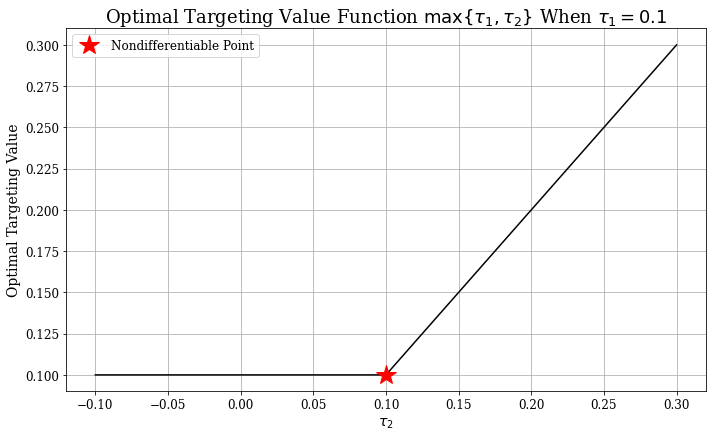

In [8]:
tau1 = 0.1
tau2_arr = np.linspace(-0.1, 0.3, 1000)

val_arr = np.array([ts.optimize(te_arr=np.array([tau1, tau2]))[1] for tau2 in tau2_arr])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(tau2_arr, val_arr, color='black')


# mark discontinuous point
ax.plot(tau1, tau1, 'r*', markersize=20, label='Nondifferentiable Point')

# plot attributes
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_title(r'Optimal Targeting Value Function $\max\{\tau_1, \tau_2\}$ When $\tau_1 = 0.1$', fontsize=title_size)
ax.set_xlabel(r'$\tau_2$', fontsize=axis_label_size)
ax.set_ylabel('Optimal Targeting Value', fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()


# Winner's Curse

In [9]:
operations_params = {}

# dgp_params = {'te_arr': np.array([0.1, 0.15, 0.2, 0.25, 0.3]), 'noise_std': 5}
dgp_params = {'te_arr': np.array([0.1, 0.11]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

# empirical distribution of winner's curse
estimators_dict = {}

result_records = ts.repeated_experiments(
    operations_params=operations_params,
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True, 
)

emp_wc_arr = np.array([record['plugin_wc'] for record in result_records])
emp_wc_pct_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])

avg_wc = np.mean(emp_wc_arr)
avg_wc_pct = np.mean(emp_wc_pct_arr)
se_wc = np.std(emp_wc_arr) / np.sqrt(data_params['sample_size'])
se_wc_pct = np.std(emp_wc_pct_arr) / np.sqrt(data_params['sample_size'])

print(f'Average Empirical Winner\'s Curse: {avg_wc:.2f} ({se_wc:.2f})')
print(f'Average Empirical Winner\'s Curse Percentage: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 3382 tasks      | elapsed:    2.8s


Average Empirical Winner's Curse: 0.08 (0.01)
Average Empirical Winner's Curse Percentage: 75.98% (11.16%)


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.8s finished


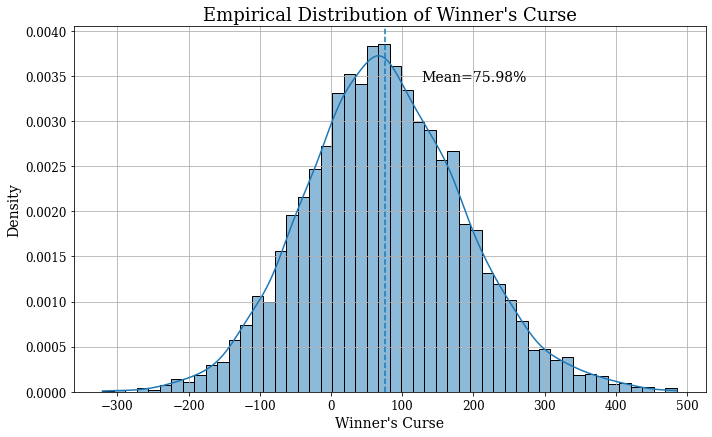

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_pct_arr, bins=50, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(emp_wc_pct_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean={emp_wc_pct_arr.mean():.2f}%", 
    xy=(0.55, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Estimating Winner's Curse

In [11]:
dgp = SingleSegment(**dgp_params)
treatment_arr, outcome_arr = dgp.sample(**data_params, seed=0)

## Standard Bootstrap

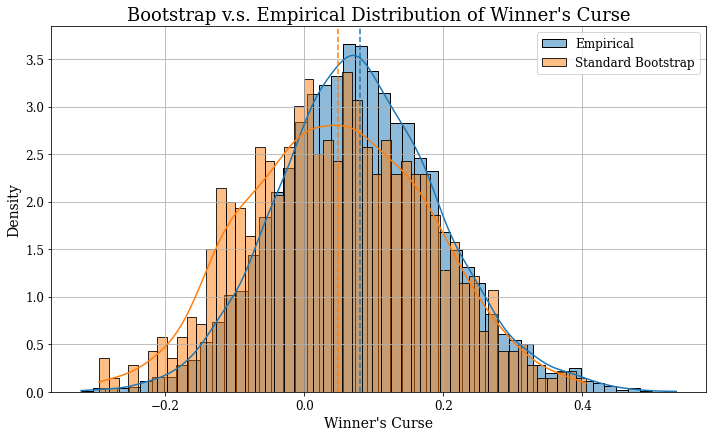

In [12]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, n_bootstraps=1000, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n bootstrap

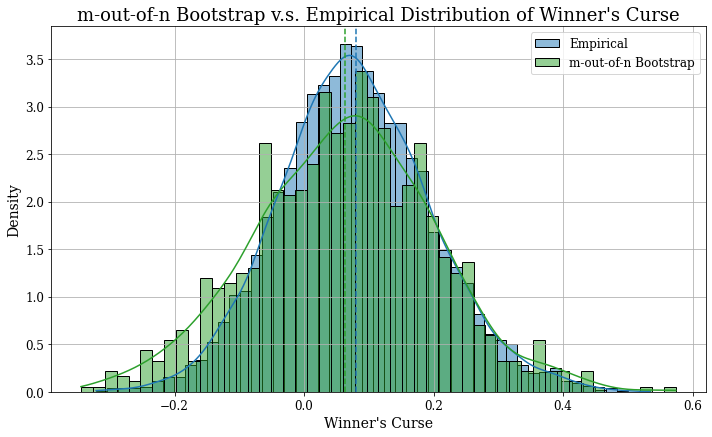

In [13]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_m_out_of_n_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, power=0.95, n_bootstraps=1000, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

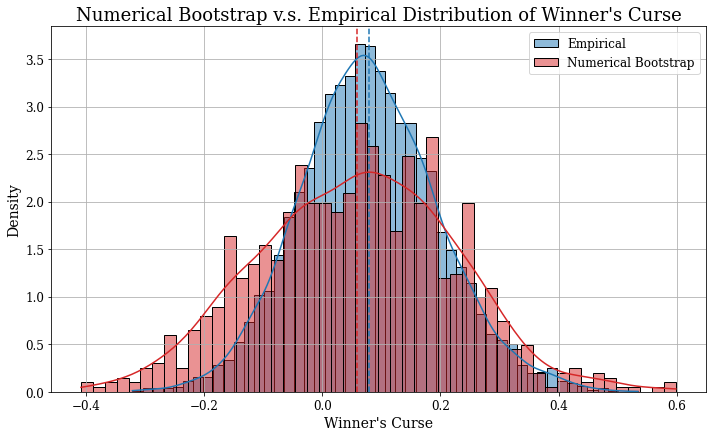

In [14]:
# generate bootstrap distribution
boot_wc_dstn_arr = ts.get_wc_num_boot_dstn(
    treatments=treatment_arr, outcomes=outcome_arr,
    **operations_params, power=-0.45, n_bootstraps=1000, conditional_on_treated=True, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(emp_wc_arr, bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [7]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 5000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.92,
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.44,
        }
    }
}

In [8]:
result_records = ts.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   27.2s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   42.4s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  2.9min finished


In [9]:
wc_df = pd.DataFrame.from_records({
    f'{name}':  np.array([record[f'{name}_wc'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = np.mean(wc_df[estimator])
    se_wc_pct = np.std(wc_df[estimator]) / np.sqrt(data_params['sample_size'])

    print(f'\nWinner\'s Curse of {estimator}: {avg_wc_pct:.4f} ({se_wc_pct:.4f})')


Winner's Curse of plugin: 0.0797 (0.0117)

Winner's Curse of standard_bootstrap: 0.0238 (0.0130)

Winner's Curse of mn_bootstrap: 0.0066 (0.0130)

Winner's Curse of num_bootstrap: 0.0062 (0.0135)


In [10]:
wc_pct_df = pd.DataFrame.from_records({
    f'{name}': 100 * np.array([record[f'{name}_wc_pct'] for record in result_records])
    for name in ['plugin'] + list(estimators_dict.keys())
})

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = np.mean(wc_pct_df[estimator])
    se_wc_pct = np.std(wc_pct_df[estimator]) / np.sqrt(data_params['sample_size'])

    print(f'\nWinner\'s Curse MPE of {estimator}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)')


Winner's Curse MPE of plugin: 75.98% (11.16%)

Winner's Curse MPE of standard_bootstrap: 22.76% (12.36%)

Winner's Curse MPE of mn_bootstrap: 6.40% (12.42%)

Winner's Curse MPE of num_bootstrap: 6.03% (12.82%)


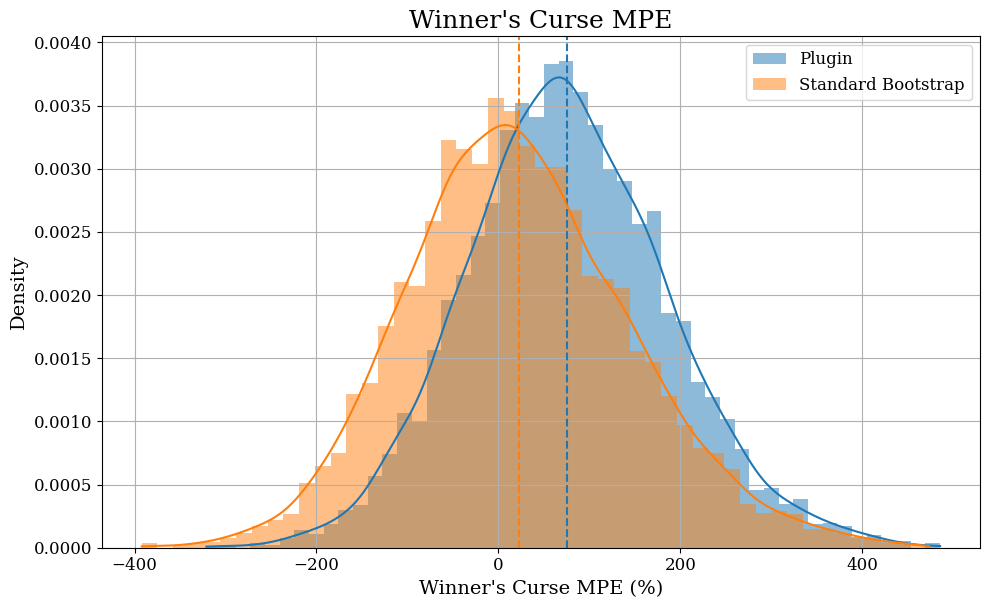

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['plugin', 'standard_bootstrap']):
    sns.histplot(
        wc_pct_df, x=estimator, bins=50, kde=True, stat='density', ax=ax, color=f'C{idx}', edgecolor=None, 
        label=model_label_map[estimator]
    )
    ax.axvline(wc_pct_df[estimator].mean(), color=f'C{idx}', linestyle='--')

ax.set_title('Winner\'s Curse MPE', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse MPE (%)', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()

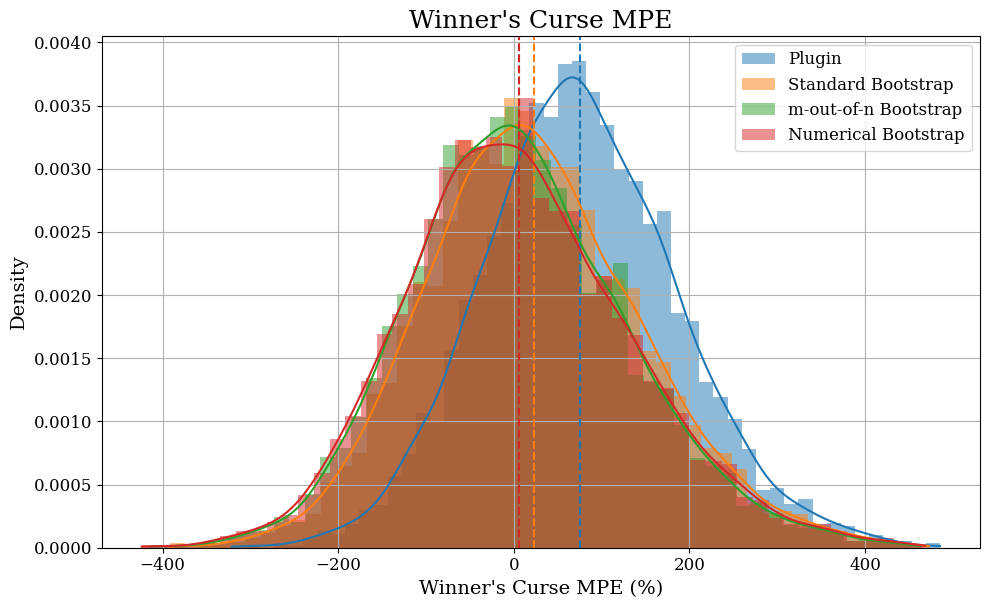

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    sns.histplot(
        wc_pct_df, x=estimator, bins=50, kde=True, stat='density', ax=ax, color=f'C{idx}', edgecolor=None, 
        label=model_label_map[estimator]
    )
    ax.axvline(wc_pct_df[estimator].mean(), color=f'C{idx}', linestyle='--')

ax.set_title('Winner\'s Curse MPE', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse MPE (%)', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-bias-correction.png')
plt.show()

# Sensitivity Analysis

## Hyperparameter w.r.t. $\tau$

### m-out-of-n bootstrap

In [13]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan,
        }
    }, 
}

In [ ]:
tau2_list = [-0.1, -0.05, 0, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2]
power_list = [0.88, 0.90, 0.92, 0.95, 0.97]
result_dict = {(tau2, power): None for tau2 in tau2_list for power in power_list}

for tau2 in tau2_list:
    dgp_params['te_arr'][1] = tau2
    for power in power_list: 
        print(f'Tau2 = {tau2}, Power = {power}')
        estimators_dict['mn_bootstrap']['params']['power'] = power
        
        result_record = ts.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(tau2, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau2, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/ts_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [16]:
with open('results/ts_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'standard_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'mn_bootstrap_mean']]
    best_wc_list[idx] = temp['mn_bootstrap_mean'].loc[(-temp['mn_bootstrap_mean'].abs()).idxmax()]

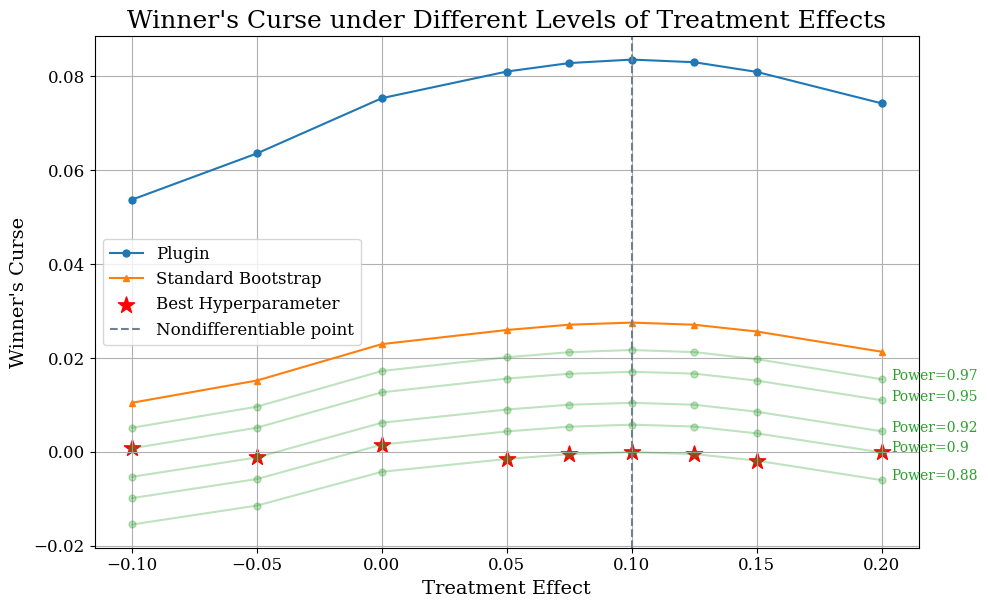

In [30]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['standard_bootstrap_mean'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'mn_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['mn_bootstrap_mean'], 'o-', color='C2', alpha=0.3, markersize=5)
    ax.text(
        mnb_df['tau'].values[-1] * 1.02, mnb_df['mn_bootstrap_mean'].values[-1] * 0.99, 
        f'Power={power}', 
        fontsize=10, color='C2'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(dgp_params['te_arr'][0], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/ts-mnb-hyperparam-test.png')
plt.show()

### Numerical bootstrap

In [31]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': np.nan, 
        }
    }
}

In [ ]:
tau2_list = [-0.1, -0.05, 0, 0.05, 0.075, 0.1, 0.125, 0.15, 0.2]
power_list = [-0.40, -0.41, -0.42, -0.43, -0.44, -0.45, -0.46, -0.47, -0.48, -0.49]
result_dict = {(tau2, power): None for tau2 in tau2_list for power in power_list}

for tau2 in tau2_list:
    dgp_params['te_arr'][1] = tau2
    for power in power_list: 
        print(f'Tau2 = {tau2}, Power = {power}')
        estimators_dict['num_bootstrap']['params']['power'] = power
        
        result_record = ts.repeated_experiments(
            operations_params=operations_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True, n_jobs=-1
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_record]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(tau2, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(tau2, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/ts_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [44]:
with open('results/ts_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_records([
    {
        'tau': tau, 'power': power, 
        **result_dict[(tau, power)]
    } for tau, power in result_dict.keys()
])

result_df = result_df[result_df['power'].isin([-0.40, -0.42, -0.44, -0.46, -0.48])]

tau_arr = np.unique(result_df['tau'])
power_arr = np.unique(result_df['power'])

plugin_df = result_df[result_df['power'] == power_arr[0]][['tau', 'plugin_mean']]
bootstrap_df = result_df[result_df['power'] == power_arr[0]][['tau', 'standard_bootstrap_mean']]
best_wc_list = [None] * len(tau_arr)
for idx, tau in enumerate(tau_arr):
    temp = result_df[result_df['tau'] == tau][['power', 'num_bootstrap_mean']]
    best_wc_list[idx] = temp['num_bootstrap_mean'].loc[(-temp['num_bootstrap_mean'].abs()).idxmax()]

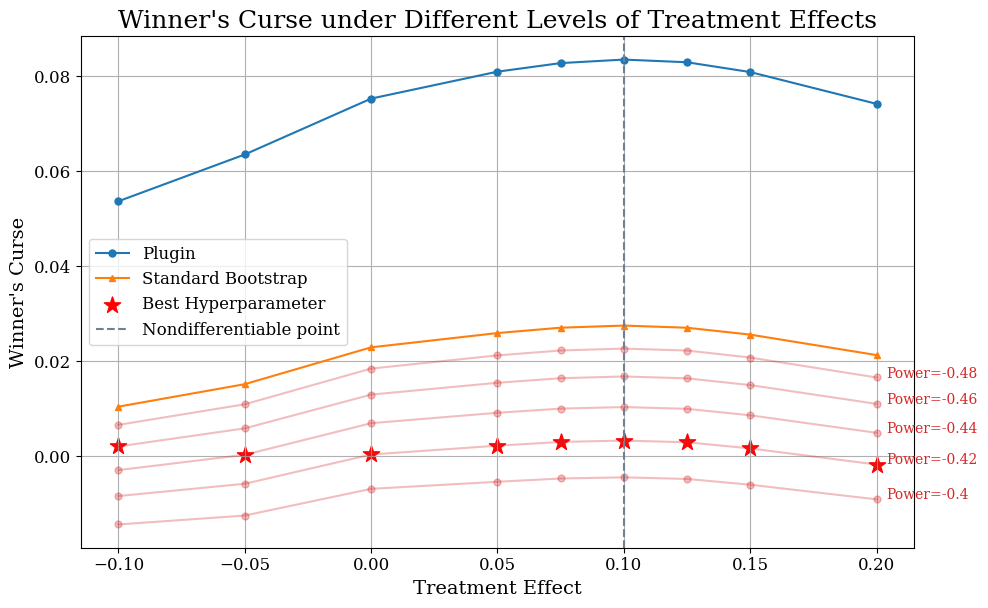

In [45]:
fig, ax = plt.subplots(figsize=(10, 6.18))

# plot plugin estimator
ax.plot(plugin_df['tau'], plugin_df['plugin_mean'], 'o-', markersize=5, label='Plugin', color='C0')

# plot bootstrap estimator
ax.plot(bootstrap_df['tau'], bootstrap_df['standard_bootstrap_mean'], '^-', markersize=5, label='Standard Bootstrap', color='C1')

# plot m out of n bootstrap estimator
for power in power_arr:
    mnb_df = result_df[result_df['power'] == power][['tau', 'num_bootstrap_mean']]
    ax.plot(mnb_df['tau'], mnb_df['num_bootstrap_mean'], 'o-', color='C3', alpha=0.3, markersize=5)
    ax.text(
        mnb_df['tau'].values[-1] * 1.02, mnb_df['num_bootstrap_mean'].values[-1] * 0.99, 
        f'Power={power}', 
        fontsize=10, color='C3'
    )

# mark the best hyperparameters for each tau
ax.scatter(tau_arr, best_wc_list, color='red', marker='*', s=150, label='Best Hyperparameter')

# plot the nondifferentiable point
ax.axvline(dgp_params['te_arr'][0], color='slategray', linestyle='--', label='Nondifferentiable point')

ax.set_title("Winner's Curse under Different Levels of Treatment Effects", fontsize=title_size)
ax.set_xlabel('Treatment Effect', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.legend(loc='best', fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/ts-numb-hyperparam-test.png')
plt.show()

## Diff in treatment effects

In [5]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, np.nan]), 'noise_std': 1}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': np.nan,
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': np.nan,
        }
    }
}

In [6]:
params_records = [
    {'te_diff': 0.005, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.01, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.05, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.1, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.15, 'mn_power': 0.88, 'num_power': -0.42},
    {'te_diff': 0.2, 'mn_power': 0.88, 'num_power': -0.42},
]

result_dict = ts.te_diff_test(
    params_records=params_records, 
    operations_params=operations_params,
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    n_jobs=-1, verbose=True, 
    save_path='results/ts_tediff_test.pkl'
)


Running with treatment effects = (0.1000, 0.1050)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   27.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   35.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished te diff 0.005 in 0:00:35.665039
Running with treatment effects = (0.1000, 0.1100)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   25.3s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   33.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished te diff 0.01 in 0:00:33.855151
Running with treatment effects = (0.1000, 0.1500)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   33.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished te diff 0.05 in 0:00:33.638744
Running with treatment effects = (0.1000, 0.2000)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   33.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Finished te diff 0.1 in 0:00:33.677133
Running with treatment effects = (0.1000, 0.2500)...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    4.9s


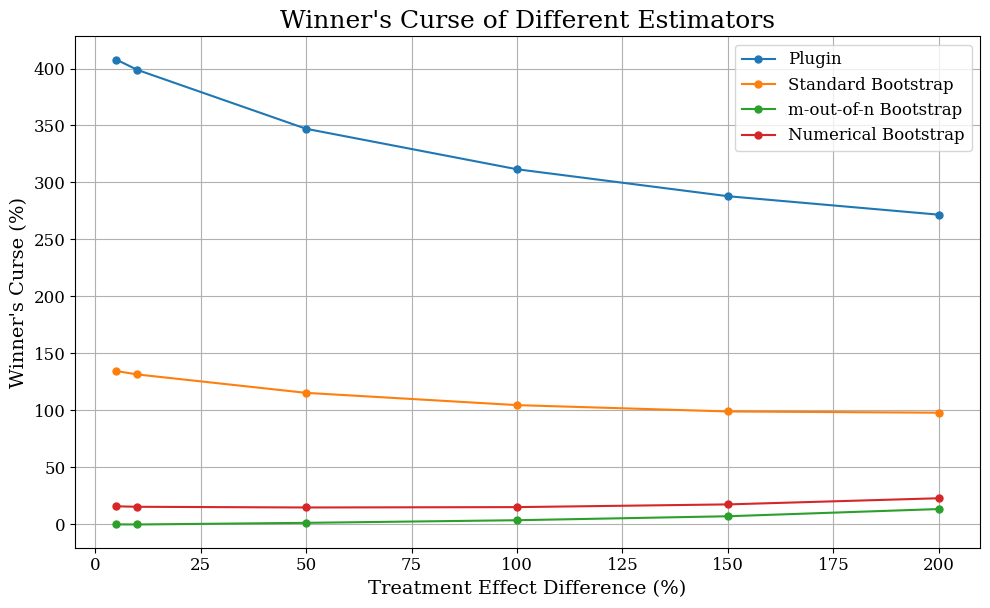

In [11]:
with open('results/ts_tediff_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

result_df.index = 100 *  result_df.index / 0.1

ts.visualize_sensitivity_test(
    estimators_list=['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='wc_pct', 
    plot_error_bar=False, 
    title='Winner\'s Curse of Different Estimators',
    model_label_map=model_label_map, 
    label='Treatment Effect Difference (%)',
    save_path=None
)

## Noise level

In [5]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.11]), 'noise_std': np.nan}

data_params = {'sample_size': 100}

experiment_params = {'n_experiments': 1000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.88,
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': -0.42,
        }
    }
}

In [ ]:
noise_level_list = [0.1, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]

result_dict = ts.noise_level_test(
    noise_levels=noise_level_list, 
    operations_params=operations_params,
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    n_jobs=-1, verbose=True, 
    save_path='results/ts_noise_level_test.pkl'
)

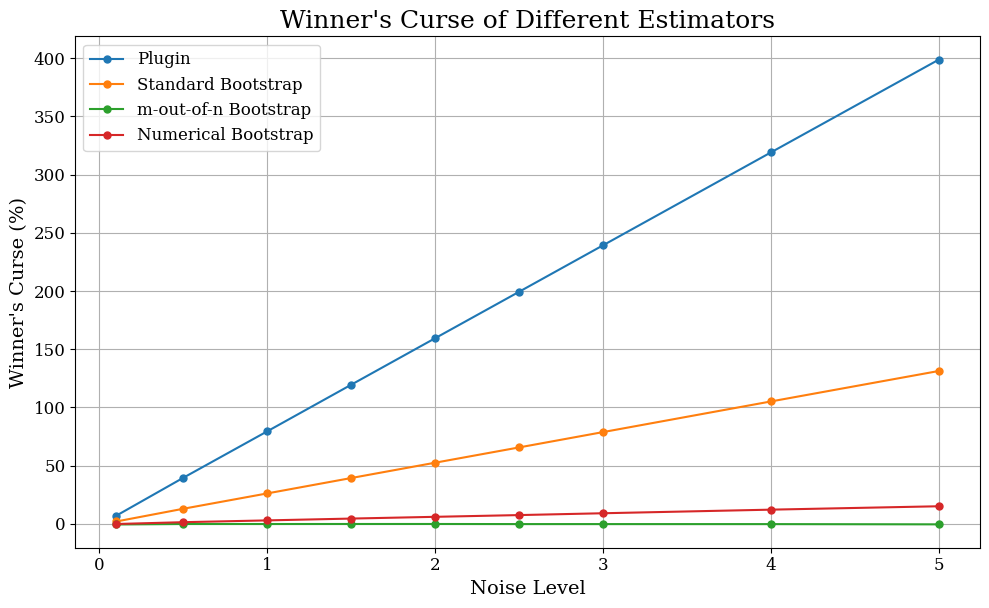

In [9]:
with open('results/ts_noise_level_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

ts.visualize_sensitivity_test(
    estimators_list=['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='wc_pct', 
    plot_error_bar=False, 
    title='Winner\'s Curse of Different Estimators',
    model_label_map=model_label_map, 
    label='Noise Level',
    save_path=None
)

## Sample size

In [19]:
operations_params = {}

dgp_params = {'te_arr': np.array([0.1, 0.15, 0.2, 0.25, 0.3]), 'noise_std': 5}

data_params = {'sample_size': 500}

experiment_params = {'n_experiments': 10000, 'stats': 'mean'} 

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'standard',
        }
    }, 
    'mn_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.92,
        }
    }, 
    'num_bootstrap': {
        'estimator': ts.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 1000, 'bootstrap_method': 'numerical', 
            'power': - 0.44,
        }
    }
}

In [ ]:
sample_size_list = [100, 200, 300, 400, 500, 750, 1000, 2000, 3000, 4000, 5000]

result_dict = ts.sample_size_test(
    sample_sizes=sample_size_list, 
    operations_params=operations_params,
    dgp_params=dgp_params,
    data_params=data_params,
    experiment_params=experiment_params,
    estimators_dict=estimators_dict,
    n_jobs=-1, verbose=True, 
    save_path='results/ts_sample_size_test.pkl'
)

In [21]:
with open('results/ts_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame.from_dict(result_dict).T

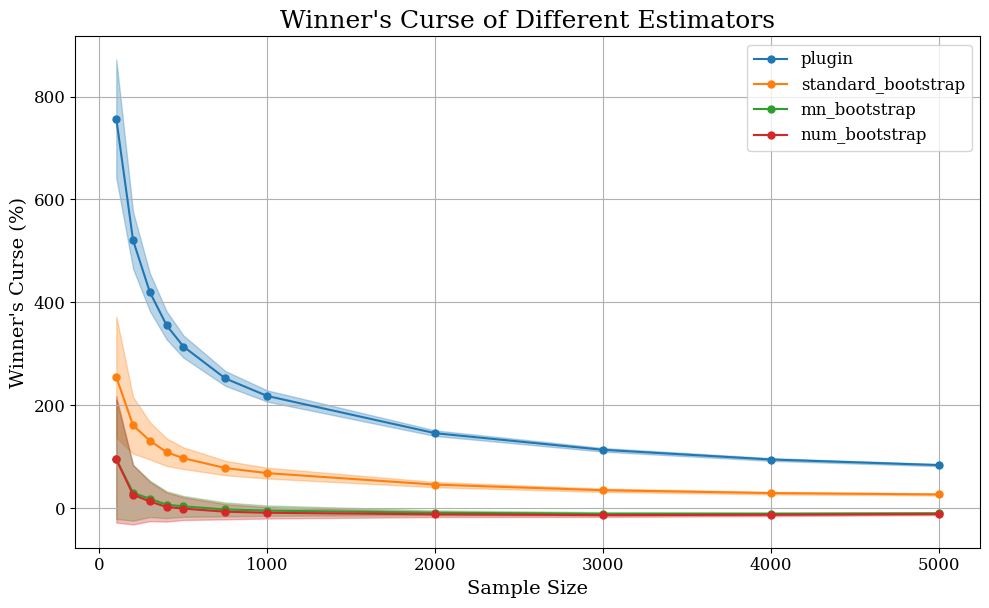

In [23]:
visualize_sensitivity_test(
    estimators_list=['plugin', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap'], 
    result_df=result_df, metric='wc_pct', plot_error_bar=True, label='Sample Size',
    save_path=None
)